# Fractalkine / CX3CL1: differential responses to human acute exercise

**Question:** Does circulating fractalkine respond to endurance or resistance exercise, when does it respond, and do muscle/adipose CX3CL1 RNA results provide compatible tissue context?

[Human data collection](https://motrpac-data.org/data-download/file-browser/analysis/human-precovid-sed-adu/c2.0) · [Pinned public package](https://github.com/MoTrPAC/MotrpacHumanPreSuspensionAnalysis/tree/535b4044e7417413de471104c619120337602b77) 

## 1. Study design and analysis decisions

The study includes 175 sedentary adults across all assays, assigned to endurance exercise (**EE**), resistance exercise (**RE**), or resting control (**CON**). This release focuses on one **acute bout**, before long-term training adaptation.

| Analysis | Estimand | Role |
|---|---|---|
| EE–CON / RE–CON | Exercise-arm change from baseline minus time-matched control change | Primary response analysis |
| EE–RE | Difference between changes in the two exercise arms | Direct modality comparison |
| EE–EE / RE–RE / CON–CON | Within-arm change from baseline | Descriptive check of the role of controls |

Blood/plasma early recovery = 30 min, muscle = 15 min, adipose = 45 min; intermediate recovery = 3.5 h in plasma/muscle and 4 h in adipose. During-exercise samples exist for EE and controls, not RE. Post-exercise times are measured from the end of each protocol.

Motrpac data includes:

  • Effect estimates (logFC)
  • Confidence intervals
  • Raw p-values (p_value)
  • BH-adjusted p-values (adj_p_value)

In [4]:
from pathlib import Path
import hashlib
import importlib.metadata
import json
import platform
import shutil
import subprocess
import sys
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

def locate_project():
    here = Path.cwd().resolve()
    for parent in [here, *here.parents]:
        for candidate in (parent, parent / 'BIC'):
            if (candidate / 'analysis/extract_fractalkine.R').is_file() and (candidate / 'motrpac-exploration').is_dir():
                return candidate
    raise FileNotFoundError('Open the notebook from the BIC directory or one of its subdirectories.')

ROOT = locate_project()
DATA = ROOT / 'motrpac-exploration'
OUT = ROOT / 'results/fractalkine'
OUT.mkdir(parents=True, exist_ok=True)
ALPHA = 0.05
GENE = 'CX3CL1'
COMMIT = '535b4044e7417413de471104c619120337602b77'
RSCRIPT = shutil.which('Rscript')
if RSCRIPT is None and Path('/usr/local/bin/Rscript').is_file():
    RSCRIPT = '/usr/local/bin/Rscript'
if RSCRIPT is None:
    raise RuntimeError('Base R is required: install R and make Rscript available on PATH.')

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:.5g}')
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Project:', ROOT)
print('Human collection: c2.0 | gene:', GENE)
print('Python:', sys.version.split()[0], '| Rscript:', RSCRIPT)

Project: /Users/acheron/BIC
Human collection: c2.0 | gene: CX3CL1
Python: 3.9.15 | Rscript: /usr/local/bin/Rscript


## 2. Verify the frozen human inputs and extract CX3CL1

Input SHA-256 checksums must match the earlier pinned download. The base-R extractor reads eight human RNA/protein/phosphoprotein result objects and the feature-to-gene map. It retains every available CX3CL1 contrast, including nonsignificant results. It also exports the full plasma Olink universe for independent BH recalculation and volcano plots.

In [5]:
SOURCE_OBJECTS = [
    'HUMAN_FEATURE_TO_GENE', 'BLOOD_PROT_OL_DA', 'BLOOD_TRNSCRPT_DA',
    'MUSCLE_TRNSCRPT_DA', 'ADIPOSE_TRNSCRPT_DA',
    'MUSCLE_PROT_PR_DA', 'MUSCLE_PROT_PH_DA',
    'ADIPOSE_PROT_PR_DA', 'ADIPOSE_PROT_PH_DA',
]
expected = json.loads((DATA / 'table3/input_provenance.json').read_text())
assert expected['motrpac_commit'] == COMMIT
input_hashes = {}
for name in SOURCE_OBJECTS:
    path = DATA / f'{name}.rda'
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    assert digest == expected['input_sha256'][path.name], f'Input mismatch: {path.name}'
    input_hashes[path.name] = digest
print(f'Verified {len(input_hashes)} source files against the pinned human release.')

run = subprocess.run([RSCRIPT, str(ROOT / 'analysis/extract_fractalkine.R'), str(DATA), str(OUT)],
                     check=True, text=True, capture_output=True)
print(run.stdout)
if run.stderr.strip():
    print(run.stderr)

results = pd.read_csv(OUT / 'cx3cl1_source_contrasts.csv')
coverage = pd.read_csv(OUT / 'cx3cl1_assay_coverage.csv')
mapping = pd.read_csv(OUT / 'cx3cl1_feature_mapping.csv')
background = pd.read_csv(OUT / 'plasma_olink_background.csv')
display(coverage)
display(mapping)

Verified 9 source files against the pinned human release.
BLOOD_PROT_OL_DA : 33 CX3CL1 contrast rows
BLOOD_TRNSCRPT_DA : 0 CX3CL1 contrast rows
MUSCLE_TRNSCRPT_DA : 21 CX3CL1 contrast rows
ADIPOSE_TRNSCRPT_DA : 21 CX3CL1 contrast rows
MUSCLE_PROT_PR_DA : 0 CX3CL1 contrast rows
MUSCLE_PROT_PH_DA : 0 CX3CL1 contrast rows
ADIPOSE_PROT_PR_DA : 0 CX3CL1 contrast rows
ADIPOSE_PROT_PH_DA : 0 CX3CL1 contrast rows
Extracted 75 CX3CL1 rows from human c2.0 cached source objects.



,source_object,tissue,assay,total_analyzed_features,mapped_CX3CL1_features,analyzed_CX3CL1_features,CX3CL1_contrast_rows
0,BLOOD_PROT_OL_DA,blood,prot-ol,1417,1,1,33
1,BLOOD_TRNSCRPT_DA,blood,transcript-rna-seq,20526,1,0,0
2,MUSCLE_TRNSCRPT_DA,muscle,transcript-rna-seq,16509,1,1,21
3,ADIPOSE_TRNSCRPT_DA,adipose,transcript-rna-seq,20090,1,1,21
4,MUSCLE_PROT_PR_DA,muscle,prot-pr,6211,0,0,0
5,MUSCLE_PROT_PH_DA,muscle,prot-ph,18164,0,0,0
6,ADIPOSE_PROT_PR_DA,adipose,prot-pr,7056,0,0,0
7,ADIPOSE_PROT_PH_DA,adipose,prot-ph,8713,0,0,0


,assay,feature_id,gene_symbol
0,epigen-atac-seq,chr16:57371275-57373273,CX3CL1
1,epigen-atac-seq,chr16:57373285-57373801,CX3CL1
2,epigen-atac-seq,chr16:57377259-57377735,CX3CL1
3,epigen-atac-seq,chr16:57381170-57381566,CX3CL1
4,epigen-atac-seq,chr16:57382137-57383346,CX3CL1
5,epigen-atac-seq,chr16:57383359-57384966,CX3CL1
6,epigen-methylcap-seq,chr16:57372345-57372381,CX3CL1
7,epigen-methylcap-seq,chr16:57377542-57377542,CX3CL1
8,epigen-methylcap-seq,chr16:57377593-57377593,CX3CL1
9,epigen-methylcap-seq,chr16:57381865-57381865,CX3CL1


An analyzed-feature count of zero means there is no CX3CL1 result in that analyzed assay table. 

Not necessarily biological absence. 

- The plasma protein should map to Olink assay OID20976. 
- The tissue RNA should map to CX3CL1's Ensembl identifier. 
- Blood-cell RNA and plasma protein are separate measurement layers.

In [6]:
keys = ['source_object', 'feature_id', 'contrast_type', 'contrast_category', 'Timepoint']
assert not results.duplicated(keys).any()
assert not background.duplicated(keys).any()
assert set(results.gene_symbol) == {GENE}
assert results[['p_value', 'adj_p_value', 'logFC', 'CI.L_calculated', 'CI.R_calculated']].notna().all().all()
assert results.p_value.between(0, 1).all() and results.adj_p_value.between(0, 1).all()
assert results['CI.L_calculated'].le(results.logFC).all()
assert results.logFC.le(results['CI.R_calculated']).all()

TIMES = ['during_20_min', 'during_40_min', 'post_10_min',
         'post_15_30_45_min', 'post_3.5_4_hr', 'post_24_hr']
def time_label(row):
    if row.Timepoint == 'post_15_30_45_min':
        return 'Post ' + {'blood': '30', 'muscle': '15', 'adipose': '45'}[row.tissue] + ' min'
    if row.Timepoint == 'post_3.5_4_hr':
        return 'Post ' + ('4' if row.tissue == 'adipose' else '3.5') + ' h'
    return {'during_20_min': 'During 20 min', 'during_40_min': 'During 40 min',
            'post_10_min': 'Post 10 min', 'post_24_hr': 'Post 24 h',
            'pre_exercise': 'Baseline'}[row.Timepoint]

results['time_label'] = results.apply(time_label, axis=1)
results['source_significant'] = results.adj_p_value < ALPHA
results['time_order'] = results.Timepoint.map({t: i for i, t in enumerate(TIMES)})
primary = results[results.contrast_type.eq('exercise_with_controls')].copy()
plasma = primary[primary.assay.eq('prot-ol')].sort_values(['contrast_category', 'time_order']).copy()
direct = results[results.contrast_type.eq('Endur_vs_Resist')].copy()
plasma_direct = direct[direct.assay.eq('prot-ol')].sort_values('time_order').copy()
rna = primary[primary.assay.eq('transcript-rna-seq')].copy()
assert len(plasma) == 10 and len(plasma_direct) == 4
assert set(plasma.feature_id) == {'OID20976'}
assert set(plasma.loc[plasma.contrast_category.eq('EE-CON'), 'Timepoint']) == set(TIMES)
assert set(plasma.loc[plasma.contrast_category.eq('RE-CON'), 'Timepoint']) == set(TIMES[2:])

display(results.groupby(['tissue', 'assay', 'contrast_type']).size().rename('rows').reset_index())

,tissue,assay,contrast_type,rows
0,adipose,transcript-rna-seq,Endur_vs_Resist,3
1,adipose,transcript-rna-seq,baseline,3
2,adipose,transcript-rna-seq,control_only,3
3,adipose,transcript-rna-seq,exercise_no_controls,6
4,adipose,transcript-rna-seq,exercise_with_controls,6
5,blood,prot-ol,Endur_vs_Resist,4
6,blood,prot-ol,baseline,3
7,blood,prot-ol,control_only,6
8,blood,prot-ol,exercise_no_controls,10
9,blood,prot-ol,exercise_with_controls,10


## 3. Calculate plasma multiple-testing adjustment independently

Benjamini–Hochberg (BH) is calculated using all analyzed Olink features for each comparison, before focusing on CX3CL1. Threshold 0.05. This is a helpful test to control for false discovery rate when running many hypothesis tests at the same time.

This is already completed in the motrpac data package, but we independently recalculate and assert that the BH p-values match.

In [7]:
def bh_adjust(values):
    p = np.asarray(values, dtype=float)
    assert np.isfinite(p).all() and ((p >= 0) & (p <= 1)).all()
    order = np.argsort(p, kind='stable')
    q = np.minimum.accumulate((p[order] * len(p) / np.arange(1, len(p) + 1))[::-1])[::-1]
    out = np.empty(len(p))
    out[order] = np.minimum(q, 1)
    return out

def holm_adjust(values):
    p = np.asarray(values, dtype=float)
    order = np.argsort(p, kind='stable')
    adjusted = np.maximum.accumulate(p[order] * np.arange(len(p), 0, -1))
    out = np.empty(len(p))
    out[order] = np.minimum(adjusted, 1)
    return out

family = ['tissue', 'assay', 'platform', 'contrast']
background['bh_recomputed'] = background.groupby(family, observed=True, dropna=False).p_value.transform(bh_adjust)
np.testing.assert_allclose(background.bh_recomputed, background.adj_p_value, rtol=1e-10, atol=1e-12)
background['p_rank_in_assay'] = background.groupby(family, observed=True, dropna=False).p_value.rank(method='min')
background['n_features_in_assay'] = background.groupby(family, observed=True, dropna=False).feature_id.transform('size')
checks = background.groupby(['contrast_category', 'Timepoint']).agg(
    n_features=('feature_id', 'size'), source_FDR_hits=('adj_p_value', lambda p: int((p < ALPHA).sum())))
print('Maximum absolute BH difference:', float((background.bh_recomputed - background.adj_p_value).abs().max()))
display(checks.reset_index())

plasma = plasma.merge(background[['feature_id', 'contrast', 'bh_recomputed', 'p_rank_in_assay', 'n_features_in_assay']],
                      on=['feature_id', 'contrast'], validate='one_to_one')
plasma['holm_10_plasma_tests'] = holm_adjust(plasma.p_value)
plasma_direct['holm_4_direct_tests'] = holm_adjust(plasma_direct.p_value)

Maximum absolute BH difference: 4.3298697960381105e-14


,contrast_category,Timepoint,n_features,source_FDR_hits
0,EE-CON,during_20_min,1417,33
1,EE-CON,during_40_min,1417,133
2,EE-CON,post_10_min,1417,18
3,EE-CON,post_15_30_45_min,1417,7
4,EE-CON,post_24_hr,1417,1
5,EE-CON,post_3.5_4_hr,1417,8
6,EE-RE,post_10_min,1417,0
7,EE-RE,post_15_30_45_min,1417,0
8,EE-RE,post_24_hr,1417,1
9,EE-RE,post_3.5_4_hr,1417,0


1. MoTrPAC tested 1,417 separate hypotheses, one for each protein assay feature.

2. For each feature, the null was:

     > Its change from baseline during endurance exercise equals its change from baseline during rest.

3. Each test produced its own raw p-value.

4. Applying the BH decision rule to those 1,417 p-values resulted in rejected null hypotheses. 


e.g. 133 source_FDR_hits means 133 features have statistical evidence of an endurance-associated response relative to rest, under this procedure. The responses can be increases or decreases.

## 4. Primary plasma differential results for cx3cl1

Positive effects mean a greater change than in resting controls; negative effects mean a lower change. 

In [8]:
columns = ['contrast_category', 'time_label', 'logFC', 'CI.L_calculated', 'CI.R_calculated',
           'p_value', 'adj_p_value', 'holm_10_plasma_tests', 'p_rank_in_assay', 'n_features_in_assay']
display(plasma[columns])
plasma.to_csv(OUT / 'cx3cl1_plasma_differential.csv', index=False)
hits = plasma[plasma.source_significant]
print('Primary source-FDR hits:', len(hits), 'of', len(plasma), 'tests')
print('Holm sensitivity hits:', int((plasma.holm_10_plasma_tests < ALPHA).sum()))
display(hits[columns])

,contrast_category,time_label,logFC,CI.L_calculated,CI.R_calculated,p_value,adj_p_value,holm_10_plasma_tests,p_rank_in_assay,n_features_in_assay
0,EE-CON,During 20 min,0.56809,0.34521,0.79098,1.2859e-06,0.00036441,1.2859e-05,5,1417
1,EE-CON,During 40 min,0.56054,0.33235,0.78873,2.8889e-06,0.00022742,2.6e-05,18,1417
2,EE-CON,Post 10 min,0.30179,0.078901,0.52467,0.0082737,0.26053,0.066189,45,1417
3,EE-CON,Post 30 min,0.22811,0.00086696,0.45536,0.049143,0.48635,0.344,143,1417
4,EE-CON,Post 3.5 h,0.23408,-0.055783,0.52395,0.11272,0.8401,0.67635,188,1417
5,EE-CON,Post 24 h,0.14972,-0.12309,0.42254,0.28008,0.98644,1,371,1417
6,RE-CON,Post 10 min,0.15688,-0.055302,0.36907,0.1462,0.54875,0.731,376,1417
7,RE-CON,Post 30 min,0.11563,-0.093242,0.3245,0.2759,0.59524,1,655,1417
8,RE-CON,Post 3.5 h,0.084607,-0.17707,0.34629,0.52407,0.96203,1,760,1417
9,RE-CON,Post 24 h,-0.064101,-0.33275,0.20454,0.63814,0.79181,1,1142,1417


Primary source-FDR hits: 2 of 10 tests
Holm sensitivity hits: 2


,contrast_category,time_label,logFC,CI.L_calculated,CI.R_calculated,p_value,adj_p_value,holm_10_plasma_tests,p_rank_in_assay,n_features_in_assay
0,EE-CON,During 20 min,0.56809,0.34521,0.79098,1.2859e-06,0.00036441,1.2859e-05,5,1417
1,EE-CON,During 40 min,0.56054,0.33235,0.78873,2.8889e-06,0.00022742,2.6e-05,18,1417


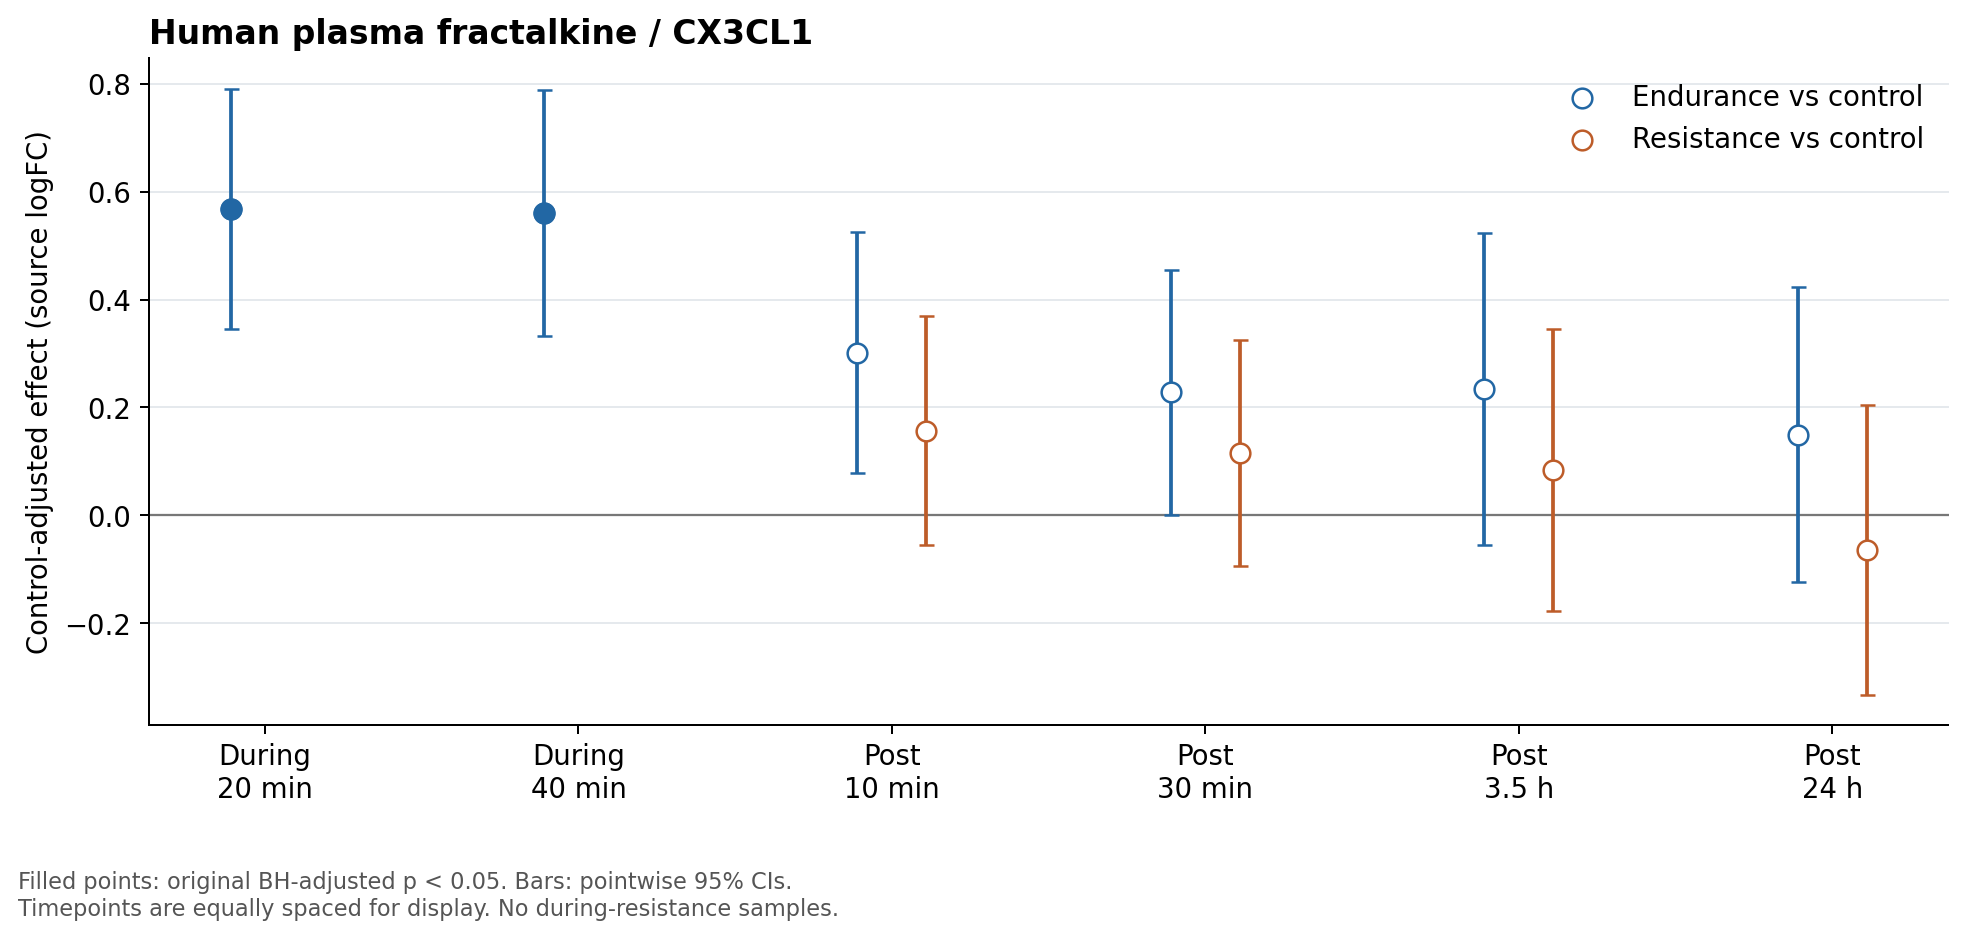

In [9]:
COLORS = {'EE-CON': '#2267a4', 'RE-CON': '#bd5c29'}
def save_figure(fig, stem):
    fig.savefig(OUT / f'{stem}.png', dpi=180, facecolor='white', bbox_inches='tight')
    fig.savefig(OUT / f'{stem}.svg', facecolor='white', bbox_inches='tight')
    display(Image(filename=str(OUT / f'{stem}.png')))
    plt.close(fig)

def response_panel(ax, frame, timepoints, labels, title):
    ax.axhline(0, color='#777', linewidth=.9)
    for group, offset, label in [('EE-CON', -.11, 'Endurance vs control'), ('RE-CON', .11, 'Resistance vs control')]:
        q = frame[frame.contrast_category.eq(group)].copy()
        q['x'] = q.Timepoint.map({t: i for i, t in enumerate(timepoints)})
        q = q.sort_values('x')
        if q.empty:
            continue
        x, y = q.x.to_numpy() + offset, q.logFC.to_numpy()
        error = np.vstack([y - q['CI.L_calculated'].to_numpy(), q['CI.R_calculated'].to_numpy() - y])
        ax.errorbar(x, y, yerr=error, fmt='none', color=COLORS[group], capsize=3)
        ax.scatter(x, y, facecolors='white', edgecolors=COLORS[group], s=62, label=label, zorder=3)
        sig = q.source_significant.to_numpy()
        ax.scatter(x[sig], y[sig], color=COLORS[group], s=62, zorder=4)
    ax.set_xticks(range(len(timepoints)), labels)
    ax.set_title(title, loc='left', fontweight='bold')
    ax.set_ylabel('Control-adjusted effect (source logFC)')
    ax.grid(axis='y', color='#e5e9ed')
    ax.set_axisbelow(True)

fig, ax = plt.subplots(figsize=(11, 5.2))
response_panel(ax, plasma, TIMES, ['During\n20 min', 'During\n40 min', 'Post\n10 min', 'Post\n30 min', 'Post\n3.5 h', 'Post\n24 h'],
               'Human plasma fractalkine / CX3CL1')
ax.legend(frameon=False)
fig.text(.01, .01, 'Filled points: original BH-adjusted p < 0.05. Bars: pointwise 95% CIs.\nTimepoints are equally spaced for display. No during-resistance samples.', fontsize=9, color='#555')
fig.tight_layout(rect=(0, .10, 1, 1))
save_figure(fig, 'cx3cl1_plasma_timecourse')

## 5. Where CX3CL1 sits in the full plasma assay

These volcano plots retain every tested Olink feature. The x-axis is the source effect and the y-axis is −log10(raw p). Blue points pass the original assay-wide FDR (ie the BH-adjusted p-values < 0.05); the red outlined point is CX3CL1. The panels illustrate the during-endurance result and matched post-exercise comparisons. They are descriptive views, not additional independent tests.

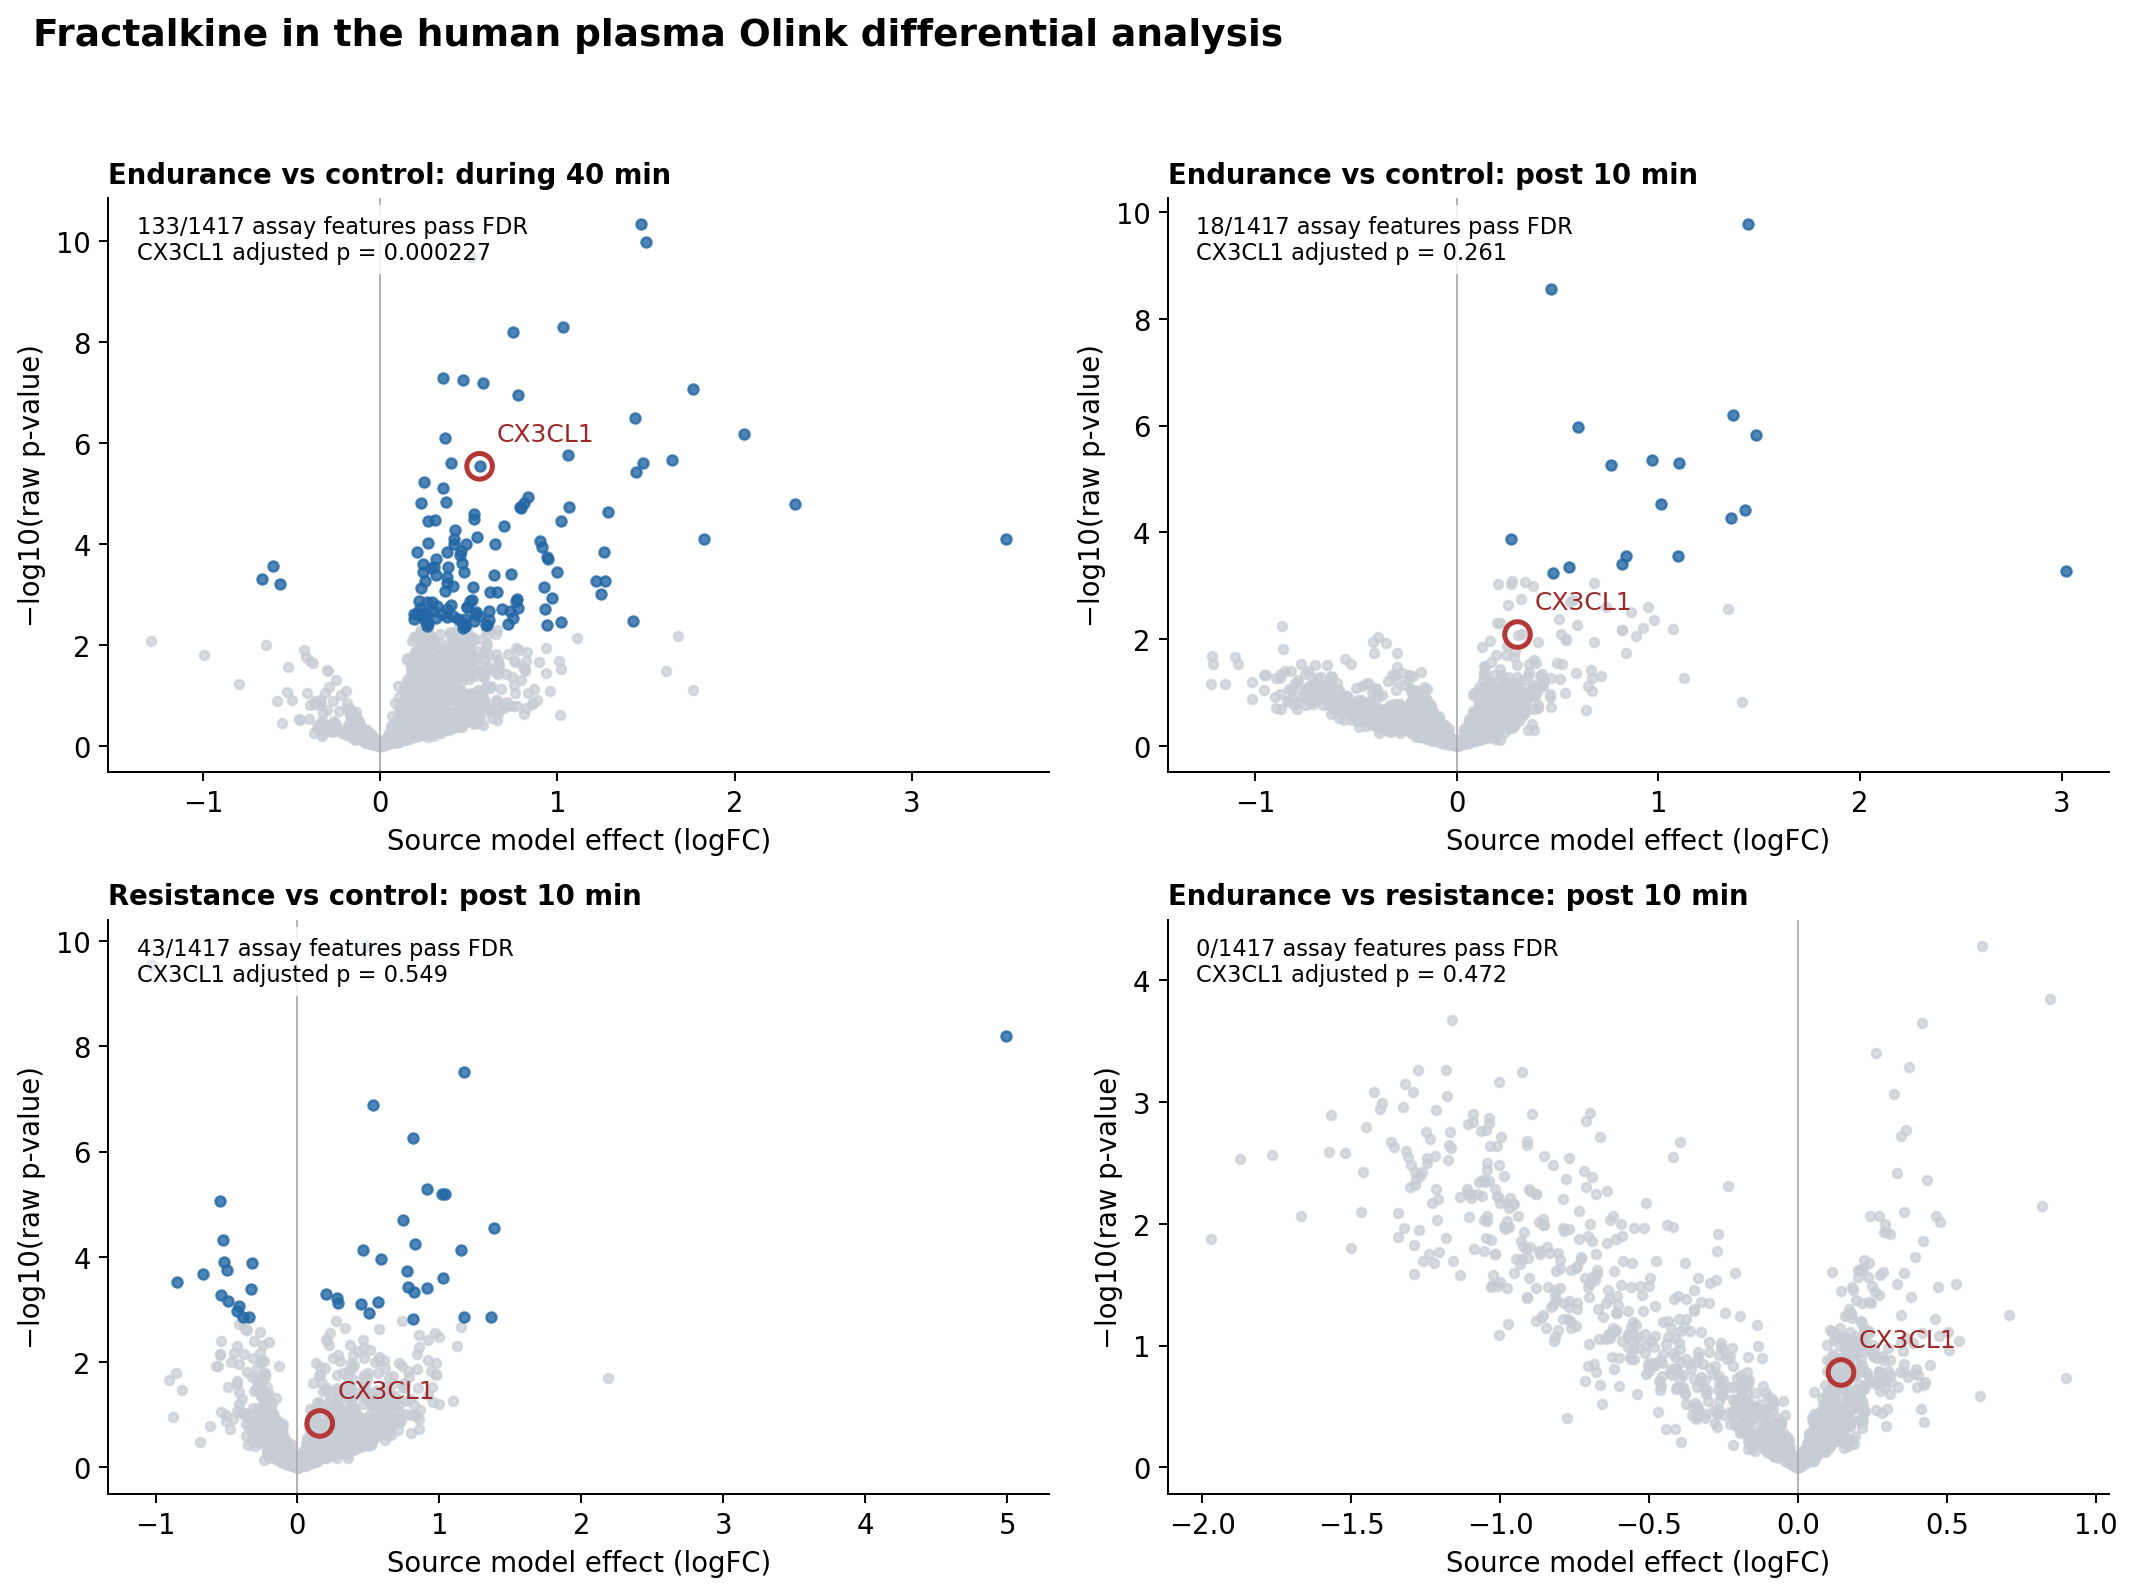

In [10]:
panels = [('EE-CON', 'during_40_min', 'Endurance vs control: during 40 min'),
          ('EE-CON', 'post_10_min', 'Endurance vs control: post 10 min'),
          ('RE-CON', 'post_10_min', 'Resistance vs control: post 10 min'),
          ('EE-RE', 'post_10_min', 'Endurance vs resistance: post 10 min')]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (group, timepoint, title) in zip(axes.flat, panels):
    q = background[background.contrast_category.eq(group) & background.Timepoint.eq(timepoint)].copy()
    y = -np.log10(q.p_value.clip(lower=np.finfo(float).tiny))
    sig = q.adj_p_value < ALPHA
    ax.scatter(q.loc[~sig, 'logFC'], y[~sig], color='#c7cdd4', s=13, alpha=.7)
    ax.scatter(q.loc[sig, 'logFC'], y[sig], color='#2267a4', s=16, alpha=.8)
    focal = q[q.feature_id.eq('OID20976')].iloc[0]
    fy = -np.log10(focal.p_value)
    ax.scatter([focal.logFC], [fy], facecolors='none', edgecolors='#b63737', linewidths=2, s=105, zorder=5)
    ax.annotate('CX3CL1', (focal.logFC, fy), xytext=(7, 10), textcoords='offset points', color='#9e2828', fontsize=10)
    ax.axvline(0, color='#aaa', linewidth=.7)
    ax.set_title(title, loc='left', fontsize=11, fontweight='bold')
    ax.set_xlabel('Source model effect (logFC)')
    ax.set_ylabel('−log10(raw p-value)')
    ax.text(.03, .97, f'{int(sig.sum())}/{len(q)} assay features pass FDR\nCX3CL1 adjusted p = {focal.adj_p_value:.3g}',
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox={'facecolor': 'white', 'alpha': .85, 'edgecolor': 'none'})
fig.suptitle('Fractalkine in the human plasma Olink differential analysis', x=.02, ha='left', fontweight='bold', fontsize=15)
fig.tight_layout(rect=(0, 0, 1, .95))
save_figure(fig, 'cx3cl1_plasma_volcano_context')

## 6. Direct endurance-versus-resistance test

An EE–RE effect tests whether the changes differ between protocols. A significant EE–CON result alongside a nonsignificant RE–CON result does not itself establish that difference. No during-exercise EE–RE comparison is possible in this release.

,time_label,logFC,CI.L_calculated,CI.R_calculated,p_value,adj_p_value,holm_4_direct_tests
20,Post 10 min,0.14491,-0.060867,0.35068,0.16624,0.47223,0.49871
12,Post 30 min,0.11248,-0.094677,0.31964,0.28519,0.99623,0.57037
0,Post 3.5 h,0.14948,-0.13048,0.42943,0.29328,0.98838,0.57037
30,Post 24 h,0.21382,-0.05533,0.48298,0.11865,0.60262,0.47461


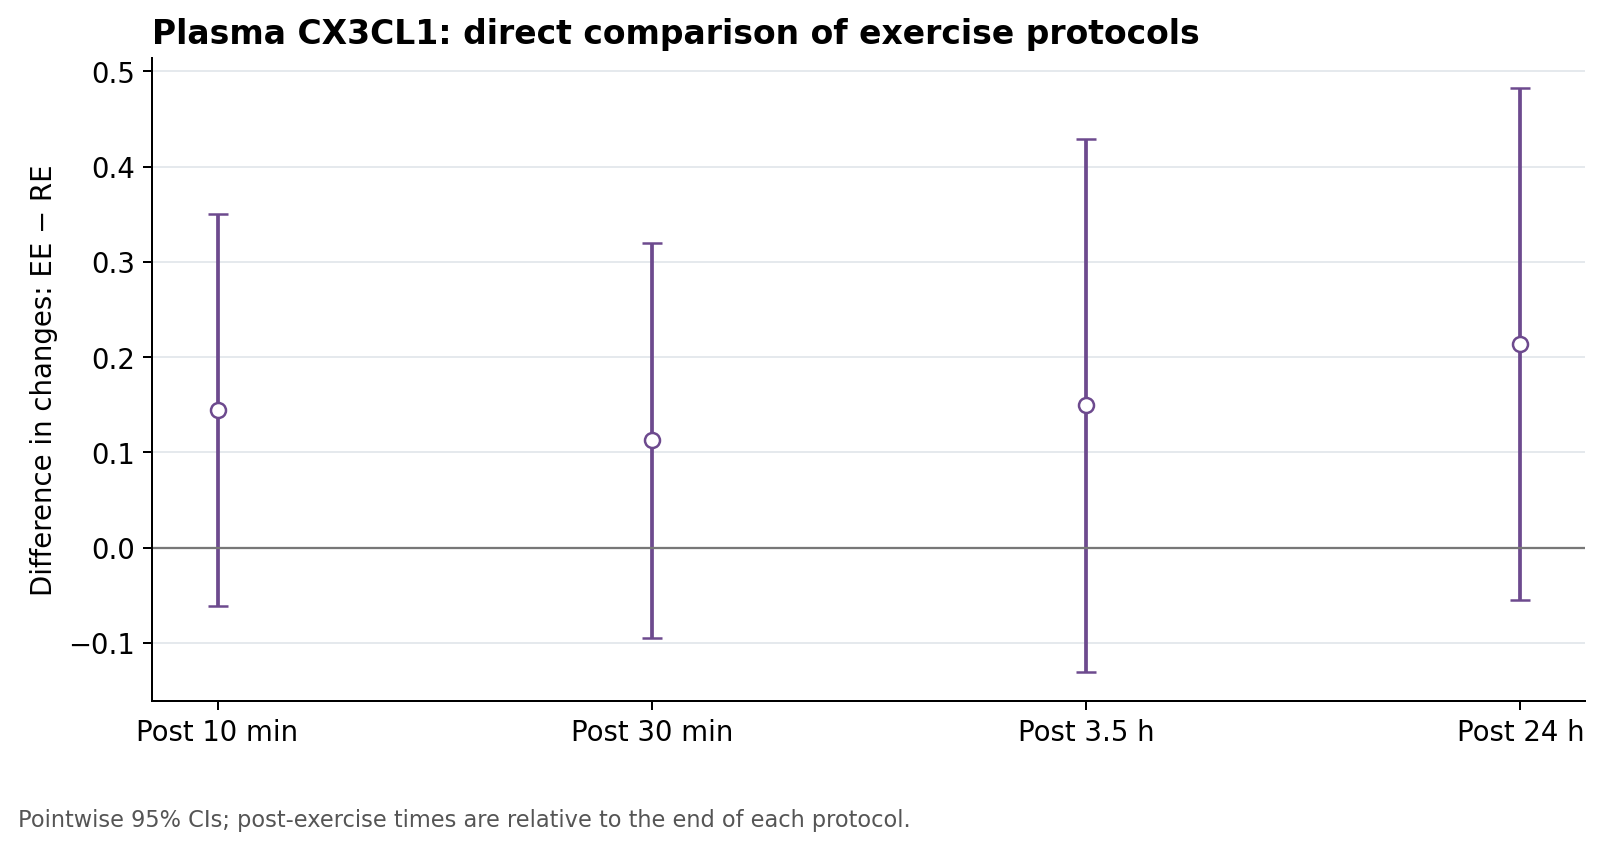

In [14]:
display(plasma_direct[['time_label', 'logFC', 'CI.L_calculated', 'CI.R_calculated', 'p_value', 'adj_p_value', 'holm_4_direct_tests']])
plasma_direct.to_csv(OUT / 'cx3cl1_plasma_endurance_vs_resistance.csv', index=False)
fig, ax = plt.subplots(figsize=(9, 4.7))
q = plasma_direct
x, y = np.arange(len(q)), q.logFC.to_numpy()
err = np.vstack([y - q['CI.L_calculated'].to_numpy(), q['CI.R_calculated'].to_numpy() - y])
ax.errorbar(x, y, yerr=err, fmt='o', markerfacecolor='white', color='#6d4a8e', capsize=4)
ax.axhline(0, color='#777', linewidth=.9)
ax.set_xticks(x, q.time_label)
ax.set_ylabel('Difference in changes: EE − RE')
ax.set_title('Plasma CX3CL1: direct comparison of exercise protocols', loc='left', fontweight='bold')
ax.grid(axis='y', color='#e5e9ed')
fig.text(.01, .01, 'Pointwise 95% CIs; post-exercise times are relative to the end of each protocol.', fontsize=9, color='#555')
fig.tight_layout(rect=(0, .07, 1, 1))
save_figure(fig, 'cx3cl1_direct_mode_comparison')

## 7. Why control-adjusted and simple pre/post results differ

This table compares the source within-arm tests with the primary exercise-versus-control tests. They estimate different quantities and have different uncertainty and multiple-testing families. A pre/post p-value cannot replace the control-adjusted result. The effect identity below checks that the source contrast estimates are internally consistent; no independence or covariance is inferred from it.

In [15]:
within = results[results.assay.eq('prot-ol') & results.contrast_type.eq('exercise_no_controls')].copy()
control = results[results.assay.eq('prot-ol') & results.contrast_type.eq('control_only')].copy()
rows = []
for _, r in plasma.iterrows():
    arm = 'EE-EE' if r.contrast_category == 'EE-CON' else 'RE-RE'
    w = within[within.contrast_category.eq(arm) & within.Timepoint.eq(r.Timepoint)].iloc[0]
    c = control[control.Timepoint.eq(r.Timepoint)].iloc[0]
    np.testing.assert_allclose(w.logFC - c.logFC, r.logFC, rtol=1e-10, atol=1e-12)
    rows.append({'exercise': r.contrast_category[:2], 'time': r.time_label,
                 'within_arm_effect': w.logFC, 'within_arm_source_q': w.adj_p_value,
                 'control_change': c.logFC, 'control_adjusted_effect': r.logFC,
                 'control_adjusted_source_q': r.adj_p_value})
control_check = pd.DataFrame(rows)
display(control_check)
control_check.to_csv(OUT / 'cx3cl1_within_arm_vs_control_adjusted.csv', index=False)

,exercise,time,within_arm_effect,within_arm_source_q,control_change,control_adjusted_effect,control_adjusted_source_q
0,EE,During 20 min,0.57919,1.8354e-09,0.0111,0.56809,0.00036441
1,EE,During 40 min,0.51665,1.7505e-07,-0.043892,0.56054,0.00022742
2,EE,Post 10 min,0.35576,0.00044895,0.053975,0.30179,0.26053
3,EE,Post 30 min,0.20615,0.28021,-0.021958,0.22811,0.48635
4,EE,Post 3.5 h,0.29349,0.20889,0.059403,0.23408,0.8401
5,EE,Post 24 h,0.3005,0.23214,0.15078,0.14972,0.98644
6,RE,Post 10 min,0.21086,0.024196,0.053975,0.15688,0.54875
7,RE,Post 30 min,0.093672,0.52244,-0.021958,0.11563,0.59524
8,RE,Post 3.5 h,0.14401,0.58929,0.059403,0.084607,0.96203
9,RE,Post 24 h,0.086679,0.88901,0.15078,-0.064101,0.79181


## 8. Muscle and adipose RNA context

These tests measure **CX3CL1 gene expression within sampled tissue**, not release of protein into plasma. Source-FDR results are shown without adding a new cross-tissue significance claim. Tissue biopsies begin after exercise, while the significant plasma measurements occur during endurance exercise; this timing cannot establish new tissue transcription as the cause of the initial circulating pulse.

,tissue,feature_id,contrast_category,time_label,logFC,CI.L_calculated,CI.R_calculated,p_value,adj_p_value
65,adipose,ENSG00000006210.7,EE-CON,Post 45 min,0.58778,0.30694,0.86862,5.3028e-05,0.027316
59,adipose,ENSG00000006210.7,EE-CON,Post 4 h,-0.14381,-0.37062,0.083,0.21266,0.88836
70,adipose,ENSG00000006210.7,EE-CON,Post 24 h,0.011637,-0.25072,0.27399,0.9304,0.99998
69,adipose,ENSG00000006210.7,RE-CON,Post 45 min,0.19088,-0.091596,0.47335,0.18429,0.81373
55,adipose,ENSG00000006210.7,RE-CON,Post 4 h,-0.11047,-0.32683,0.10589,0.31521,0.84983
68,adipose,ENSG00000006210.7,RE-CON,Post 24 h,-0.027181,-0.2909,0.23654,0.8392,0.99966
53,muscle,ENSG00000006210.7,EE-CON,Post 15 min,3.6261,3.2763,3.9758,3.332e-57,5.5008e-53
40,muscle,ENSG00000006210.7,EE-CON,Post 3.5 h,0.53648,0.15957,0.91339,0.0054386,0.041645
45,muscle,ENSG00000006210.7,EE-CON,Post 24 h,0.12738,-0.20877,0.46353,0.45633,0.75958
42,muscle,ENSG00000006210.7,RE-CON,Post 15 min,2.5854,2.2416,2.9292,7.5344e-37,1.5548e-33


**Direct EE–RE tissue RNA comparisons.** Positive effects mean a larger increase after endurance. These tests concern tissue RNA, not plasma protein.

,tissue,time_label,logFC,CI.L_calculated,CI.R_calculated,p_value,adj_p_value
57,adipose,Post 45 min,0.3969,0.15733,0.63648,0.0012709,0.31136
63,adipose,Post 4 h,-0.033337,-0.21615,0.14948,0.71952,0.99916
60,adipose,Post 24 h,0.038818,-0.18748,0.26511,0.73561,0.99983
39,muscle,Post 15 min,1.0407,0.79561,1.2857,2.3007e-15,4.2202e-12
50,muscle,Post 3.5 h,0.25385,-0.050155,0.55786,0.10135,0.23031
36,muscle,Post 24 h,0.29936,0.014653,0.58407,0.039392,0.13931


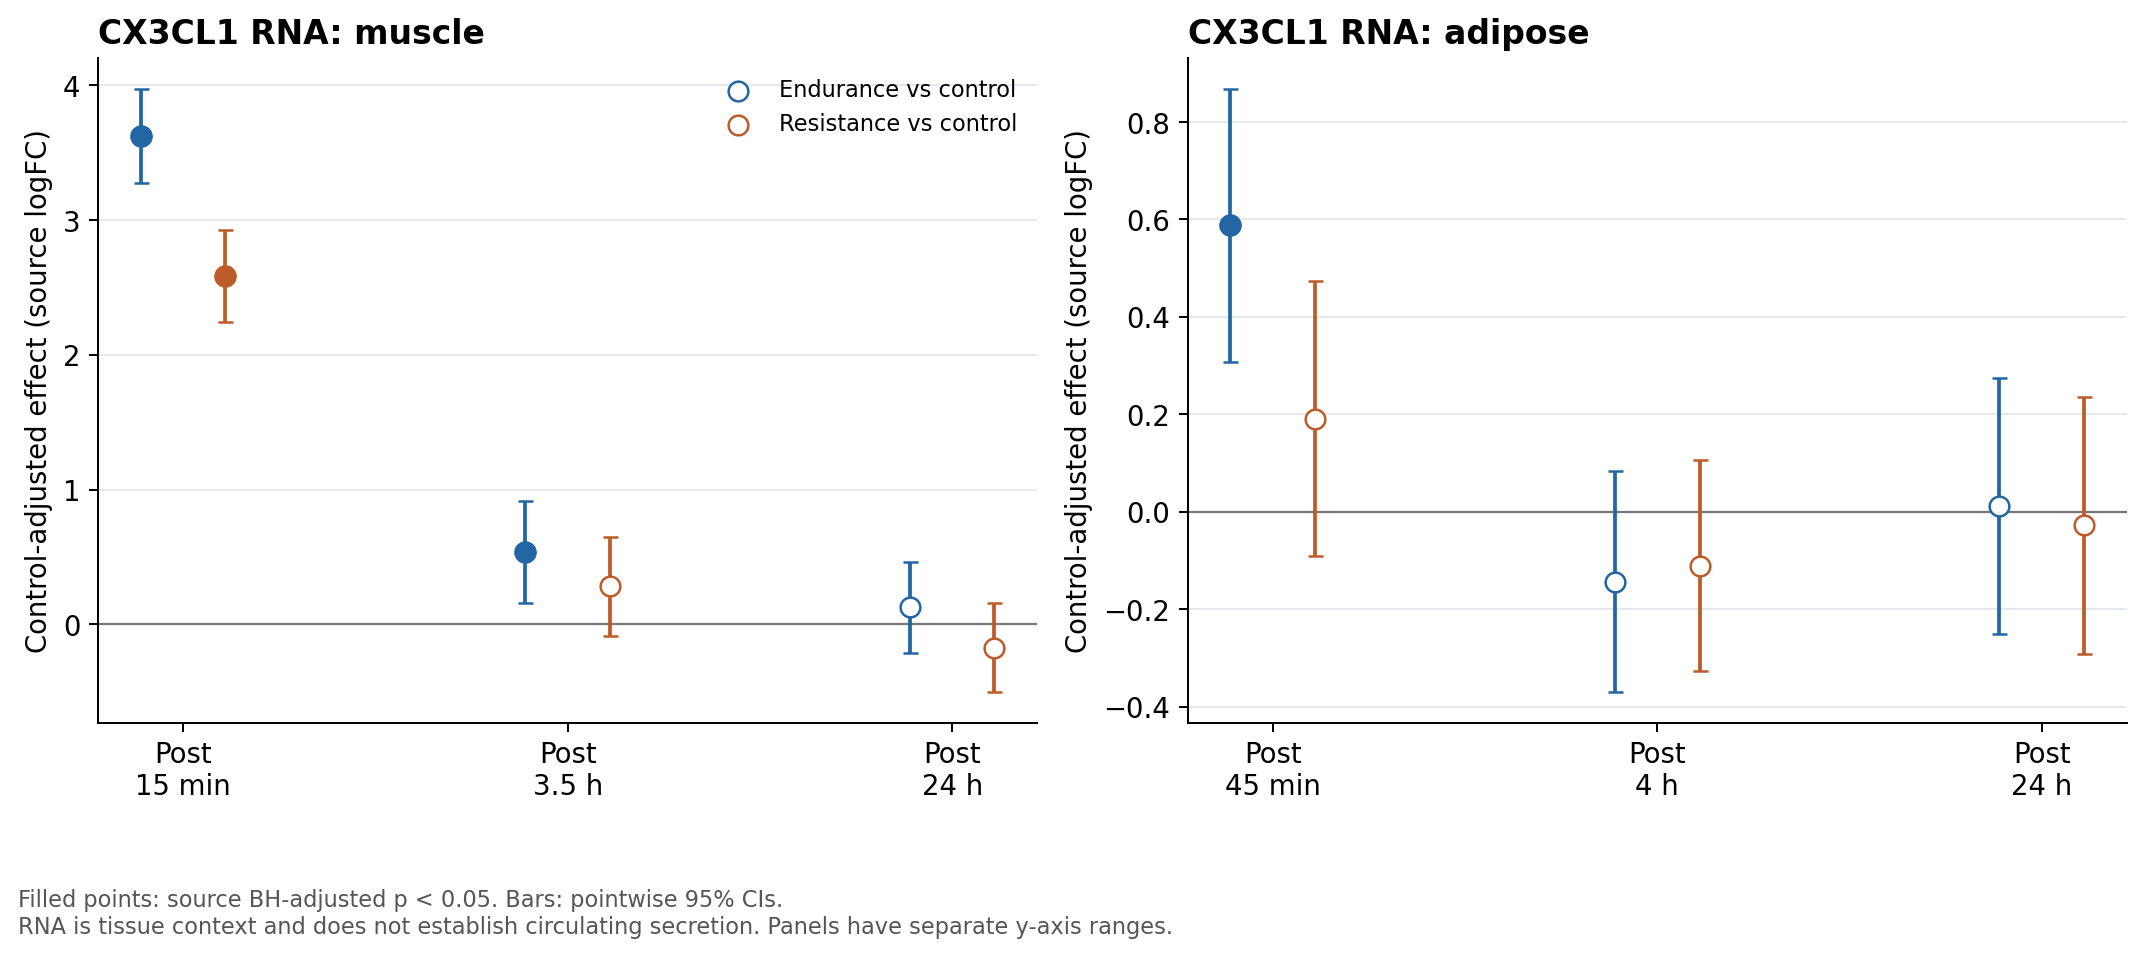

In [16]:
rna = rna.sort_values(['tissue', 'contrast_category', 'time_order'])
display(rna[['tissue', 'feature_id', 'contrast_category', 'time_label', 'logFC', 'CI.L_calculated', 'CI.R_calculated', 'p_value', 'adj_p_value']])
rna.to_csv(OUT / 'cx3cl1_tissue_rna_differential.csv', index=False)
rna_direct = direct[direct.assay.eq('transcript-rna-seq')].sort_values(['tissue', 'time_order']).copy()
display(Markdown('**Direct EE–RE tissue RNA comparisons.** Positive effects mean a larger increase after endurance. These tests concern tissue RNA, not plasma protein.'))
display(rna_direct[['tissue', 'time_label', 'logFC', 'CI.L_calculated', 'CI.R_calculated', 'p_value', 'adj_p_value']])
rna_direct.to_csv(OUT / 'cx3cl1_tissue_rna_endurance_vs_resistance.csv', index=False)
direct.to_csv(OUT / 'cx3cl1_all_direct_mode_contrasts.csv', index=False)
rna_times = ['post_15_30_45_min', 'post_3.5_4_hr', 'post_24_hr']
fig, axes = plt.subplots(1, 2, figsize=(12, 5.3))
for ax, tissue, labels in zip(axes, ['muscle', 'adipose'],
                               [['Post\n15 min', 'Post\n3.5 h', 'Post\n24 h'], ['Post\n45 min', 'Post\n4 h', 'Post\n24 h']]):
    response_panel(ax, rna[rna.tissue.eq(tissue)], rna_times, labels, f'CX3CL1 RNA: {tissue}')
axes[0].legend(frameon=False, fontsize=9)
fig.text(.01, .01, 'Filled points: source BH-adjusted p < 0.05. Bars: pointwise 95% CIs.\nRNA is tissue context and does not establish circulating secretion. Panels have separate y-axis ranges.', fontsize=9, color='#555')
fig.tight_layout(rect=(0, .12, 1, 1))
save_figure(fig, 'cx3cl1_tissue_rna_timecourse')

The human results support a transient circulating CX3CL1 response during endurance exercise, alongside post-exercise tissue RNA responses. During-resistance blood was not sampled, and the direct post-exercise plasma tests do not establish an endurance-specific response.

Tissue origin, secretion or cleavage, and clearance remain unresolved. A transcriptional response after exercise is not necessarily evidence that it generated the earlier plasma pulse. 
